# Project 4 — Token lengths in characters and bytes

**Chapter 2 · Tokenization** · pp. 35–39

Compare how long every GPT-2 token is in **characters** vs. **UTF-8 bytes** across the whole vocabulary. ASCII tokens match; accented letters, non-Latin scripts, and emoji take multiple bytes per character — and those mismatches are what we hunt down.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
### matplotlib adjustments
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top":   False,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "savefig.dpi": 300,
})

# **Demo of counting bytes**

In [3]:
things = ["x", "!", "ü", "🥰", "活"]

for t in things:
    print(f"{len(t.encode("utf-8"))} bytes in {t}")

1 bytes in x
1 bytes in !
2 bytes in ü
4 bytes in 🥰
3 bytes in 活


# **Part 1: Character vs. byte lengths in all tokens**

In [4]:
# GPT2 tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")

/Users/johnmachado/Desktop/50 ML Projects to Understand LLMs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
tokenizer

GPT2Tokenizer(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})

In [6]:
# initialize
token_lengths = np.zeros((200, 200), dtype=int)     # 2-D counter: [chars, bytes] -> how many tokens
token_lens_chars = np.zeros(tokenizer.vocab_size, dtype=int)
token_lens_bytes = np.zeros(tokenizer.vocab_size, dtype=int)


for i in range(tokenizer.vocab_size):

    # the token text for this index

    thistoken = tokenizer.decode([i])

    # its two lengths
    token_lens_chars[i] = len(thistoken)
    token_lens_bytes[i] = len(thistoken.encode("utf-8"))

    # increment the 2-D counter at [char-length, byte-length]
    token_lengths[token_lens_chars[i], token_lens_bytes[i]] += 1

### How to read `token_lengths`

It's a 2-D tally grid. **Row = character length, column = byte length.** Each cell = *how many tokens have that exact (chars, bytes) combination.* Every token dropped one marble, so the whole grid sums to 50,257 (the vocab size).

Top-left corner of the grid:

|            | **0 bytes** | **1 byte** | **2 bytes** | **3 bytes** | **4 bytes** | **5 bytes** |
|------------|:-:|:-:|:-:|:-:|:-:|:-:|
| **0 chars** | 0 | 0 | 0 | 0 | 0 | 0 |
| **1 char**  | 0 | **128** | 126 | 434 | 0 | 0 |
| **2 chars** | 0 | 0 | **1616** | 54 | 97 | 4 |
| **3 chars** | 0 | 0 | 0 | **4952** | 12 | 8 |
| **4 chars** | 0 | 0 | 0 | 0 | **7145** | 3 |
| **5 chars** | 0 | 0 | 0 | 0 | 0 | **7286** |

**Reading a cell** — go to a row, slide across to a column:

- `[1 char, 1 byte] = 128` -> 128 tokens are 1 character **and** 1 byte (plain ASCII: `a`, `!`, `7`).
- `[1 char, 2 bytes] = 126` -> 126 tokens are 1 character but **2 bytes** (one accented letter like `é`, `ü`).
- `[1 char, 3 bytes] = 434` -> 434 tokens are 1 character but **3 bytes** (one CJK char like `活`).
- `[2 chars, 2 bytes] = 1616` -> 1616 tokens are 2 characters and 2 bytes (`in`, `at`, `he`).

The total number of **1-character** tokens is that whole row added up: 128 + 126 + 434 = **688**.

**Two patterns:**
- **The diagonal** (chars = bytes: 128, 1616, 4952, 7145, 7286 ...) is plain English — 1 byte per character. Most of the vocab lives here.
- **Above the diagonal** (bytes > chars) are the **mismatches** — multi-byte characters (accents, emoji, non-Latin scripts). Nothing ever appears *below* the diagonal, because a character always costs at least 1 byte, so bytes >= chars always.

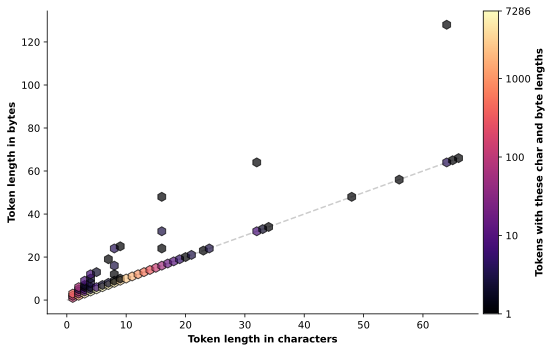

In [7]:
### draw a figure
fig = plt.figure(figsize=(8, 5))

# map each cell's frequency onto a color (log scale, because counts vary hugely)
norm = mpl.colors.Normalize(vmin=0, vmax=np.log(token_lengths.max()))

# draw one dot per nonzero cell of the grid
x, y = np.nonzero(token_lengths)
for xi, yi in zip(x, y):
    plt.plot(
        xi,
        yi,
        "kh",
        alpha=.7,
        markersize=9,
        markerfacecolor=plt.cm.magma(
            norm(np.log(token_lengths[xi, yi]))
        )
    )

# color scale legend, labeled with ACTUAL token counts (not log values)
sm = mpl.cm.ScalarMappable(cmap=mpl.cm.magma, norm=norm)
cbar = plt.colorbar(sm, ax=fig.gca(), pad=.01)

maxcount = token_lengths.max()
tickcounts = [1, 10, 100, 1000, maxcount]          # the counts we want labeled
cbar.set_ticks([np.log(t) for t in tickcounts])     # place each tick at its log position
cbar.set_ticklabels([str(int(t)) for t in tickcounts])  # but label it with the real count
cbar.set_label("Tokens with these char and byte lengths")

# draw the line of equality (chars == bytes)
plt.plot(
    [0, xi],
    [0, yi],
    "--",
    color=[.8, .8, .8],
    zorder=-100
)

# prettify
plt.gca().set(
    xlabel="Token length in characters",
    ylabel="Token length in bytes"
)

plt.tight_layout()
plt.savefig("images/ch2-proj4-pt1.png")
plt.show()

In [8]:
noteq = np.where(token_lens_chars != token_lens_bytes)[0]
print(f"There are {len(noteq)} tokens with unequal lengths.\nHere are 30:\n")

for idx in np.random.choice(noteq, 30, replace=False):
    print(tokenizer.decode([idx]), end=" | ")

There are 873 tokens with unequal lengths.
Here are 30:

� | Í | � |  � | ン | ──────── | で | � | с | � | � | � |  神 |      | 」 | � | ι | 光 | ه | ンジ |  §§ | κ | .」 | � | � | ‐ | ══ | � | ت |  ال | 

**About the `�` tokens:**

Many of these are **single-byte fragments** — one half of a multi-byte character (e.g. `é` = bytes `[195, 169]`; GPT-2 has a token for each half).

Alone, a half-byte isn't a valid character, so it displays as `�`. In real text these always appear in pairs and decode back perfectly — they only look broken because we're decoding one token at a time.

They count as mismatches because `�` is 1 character but 3 bytes.

# **Part 2: Visualizing token lengths**

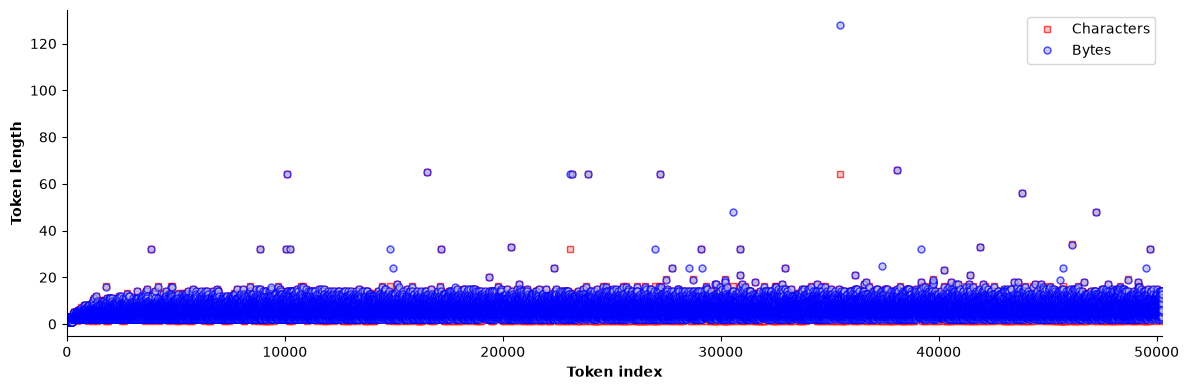

In [9]:
import matplotlib_inline.backend_inline

# This plot has ~100k markers (50k tokens x 2 series). As an SVG that's 100k
# separate elements -> laggy on hover. Render THIS cell's output as a flat PNG
# instead, then switch back to SVG for the rest of the notebook.
matplotlib_inline.backend_inline.set_matplotlib_formats("png")

plt.figure(figsize=(12, 4))

# plot all tokens
max2plot = tokenizer.vocab_size

# note: small y-offset on characters so the two series don't perfectly overlap
plt.plot(token_lens_chars[:max2plot] + .1, "rs", label="Characters", markerfacecolor=[.9, .7, .7, .7], markersize=5)
plt.plot(token_lens_bytes[:max2plot], "bo", label="Bytes", markerfacecolor=[.7, .7, .9, .7], markersize=5)

plt.legend()
plt.gca().set(xlabel="Token index", ylabel="Token length", xlim=[-10, max2plot + 10])

plt.tight_layout()
plt.savefig("images/ch2-proj4-pt2.png")
plt.show()

# restore SVG for subsequent plots
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

**How to read this plot:** each column is one token (x = its index, 0 to ~50,000). For every token there are two dots:

- **red square = its length in characters**
- **blue circle = its length in bytes**

For most tokens the two sit on top of each other (plain ASCII: 1 byte per character), so you see one blended band.

Wherever a **blue circle floats above its red square**, that token has **more bytes than characters** — a multi-byte token (accents, non-Latin scripts, emoji). Those are the same mismatches from Part 1, now shown token-by-token.

*(The red squares are nudged up slightly so they don't hide exactly behind the blue circles.)*